# Tri-Stream Multimodal Video Network for Deepfake Detection

This notebook trains the tri-stream video detector combining:
- **Stream 1 (Spatial)**: CLIP ViT-L/14 + SRM Noise (EfficientNetV2-S) with temporal pooling
- **Stream 2 (Audio)**: Dual-Feature CNN-GRU (Mel + LFCC)
- **Stream 3 (Sync)**: CLIP ViT-B/32 + Lightweight CNN + Cross-Attention + BiLSTM
- **Late Fusion**: Concat → MLP → logit

**Label Mapping**: Fake = 0, Real = 1

**Note:** The results shown in this notebook may differ from those reported in the final report, as no fixed random seed was set during training. Variations in initialization, data shuffling, and GPU non-determinism can lead to slightly different outcomes across runs.

In [ ]:
import sys, os, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

from configs import VideoTrainConfig
from models.video_detector import VideoTriStreamDetector
from data_loaders.video_dataset import TriStreamVideoDataset
from engine.trainer import train_one_epoch, EarlyStopping, unpack_video_dict
from engine.evaluator import evaluate, compute_metrics
from common.checkpoint import save_best_model
from common.visualization import (
    plot_training_history, plot_roc_curve, plot_confusion_matrix
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.backends.cudnn.benchmark = True

Using device: cuda


## 1. Configuration

In [2]:
cfg = VideoTrainConfig()
print(cfg)

VideoTrainConfig(epochs=30, batch_size=4, weight_decay=0.01, scheduler='cosine', scheduler_t_max=30, scheduler_eta_min=1e-06, early_stopping_patience=10, early_stopping_mode='max', grad_clip_max_norm=1.0, num_workers=4, num_frames=15, lr_sync_stream=5e-05, lr_fusion=0.0001, lr_classifier=0.0001, perf=PerformanceConfig(num_workers=4, pin_memory=True, persistent_workers=False, prefetch_factor=2, cudnn_benchmark=True, use_amp=True, compile_model=False, compile_backend='inductor'))


## 2. Datasets & DataLoaders

In [3]:
DATA_ROOT = '../data/video_tensors'
perf = cfg.perf

train_dataset = TriStreamVideoDataset(os.path.join(DATA_ROOT, 'train'), is_train=True)
val_dataset   = TriStreamVideoDataset(os.path.join(DATA_ROOT, 'val'),   is_train=False)
test_dataset  = TriStreamVideoDataset(os.path.join(DATA_ROOT, 'test'),  is_train=False)

loader_kwargs = dict(
    num_workers=perf.num_workers,
    pin_memory=perf.pin_memory,
    persistent_workers=perf.persistent_workers and perf.num_workers > 0,
    prefetch_factor=perf.prefetch_factor if perf.num_workers > 0 else None,
)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.batch_size, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.batch_size, shuffle=False, **loader_kwargs)

print(f'Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')
print(f'DataLoader: num_workers={perf.num_workers}, prefetch_factor={perf.prefetch_factor}, persistent_workers={perf.persistent_workers}')

Loaded 699 samples from ../data/video_tensors\train
  Fake (Class 0): 349
  Real (Class 1): 350
Loaded 151 samples from ../data/video_tensors\val
  Fake (Class 0): 76
  Real (Class 1): 75
Loaded 150 samples from ../data/video_tensors\test
  Fake (Class 0): 75
  Real (Class 1): 75
Train batches: 175, Val: 38, Test: 38
DataLoader: num_workers=4, prefetch_factor=2, persistent_workers=False


## 3. Model, Optimizer, Scheduler

In [4]:
model = VideoTriStreamDetector(
    load_image_models=True,
    image_clip_path='../saved_models/best_clip.pth',
    noise_efficientnet_path='../saved_models/best_noise_efficientnet.pth',
    audio_cnn_gru_path='../saved_models/best_audio_cnn_gru.pth',
).to(device)

if perf.compile_model:
    model = torch.compile(model, backend=perf.compile_backend)
    print(f'Model compiled with backend={perf.compile_backend}')

criterion = nn.BCEWithLogitsLoss()

param_groups = [
    {'params': model.audio_semantic_cnn.parameters(), 'lr': cfg.lr_sync_stream},
    {'params': model.audio_semantic_proj.parameters(), 'lr': cfg.lr_sync_stream},
    {'params': model.cross_attention.parameters(),     'lr': cfg.lr_sync_stream},
    {'params': model.sync_lstm.parameters(),           'lr': cfg.lr_sync_stream},
    {'params': model.stream1_fusion.parameters(),      'lr': cfg.lr_fusion},
    {'params': model.classifier.parameters(),          'lr': cfg.lr_classifier},
]

optimizer = optim.AdamW(param_groups, weight_decay=cfg.weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.scheduler_t_max, eta_min=cfg.scheduler_eta_min,
)

scaler = torch.amp.GradScaler('cuda', enabled=perf.use_amp)
print(f'AMP enabled: {perf.use_amp}')

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias     

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias      

AMP enabled: True


## 4. Training Loop

In [5]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
early_stop = EarlyStopping(patience=cfg.early_stopping_patience, mode=cfg.early_stopping_mode)
best_val_auc = 0.0

for epoch in range(cfg.epochs):
    print(f'\nEpoch {epoch+1}/{cfg.epochs}')

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        unpack_fn=unpack_video_dict,
        grad_clip=cfg.grad_clip_max_norm,
        scaler=scaler, use_amp=perf.use_amp,
    )

    val_results = evaluate(
        model, val_loader, criterion, device,
        unpack_fn=unpack_video_dict,
        use_amp=perf.use_amp,
    )

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_results['val_loss'])
    history['val_acc'].append(val_results['accuracy'])
    history['val_auc'].append(val_results['roc_auc'])

    print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
    print(f"  Val   Loss: {val_results['val_loss']:.4f} | Acc: {val_results['accuracy']*100:.2f}% | AUC: {val_results['roc_auc']:.4f}")

    if val_results['roc_auc'] > best_val_auc:
        best_val_auc = val_results['roc_auc']
        save_best_model(model, '../saved_models/best_video_tristream.pth', epoch, val_results)

    if early_stop(val_results['roc_auc']):
        break

print(f'\nBest Val AUC: {best_val_auc:.4f}')


Epoch 1/30


  Train Loss: 0.4479 | Acc: 79.26%
  Val   Loss: 0.1674 | Acc: 96.69% | AUC: 0.9918
Best model saved to ../saved_models/best_video_tristream.pth

Epoch 2/30


  Train Loss: 0.3827 | Acc: 85.41%
  Val   Loss: 0.1462 | Acc: 96.69% | AUC: 0.9935
Best model saved to ../saved_models/best_video_tristream.pth

Epoch 3/30


  Train Loss: 0.4131 | Acc: 85.41%
  Val   Loss: 0.1111 | Acc: 98.68% | AUC: 0.9958
Best model saved to ../saved_models/best_video_tristream.pth

Epoch 4/30


  Train Loss: 0.3761 | Acc: 86.84%
  Val   Loss: 0.0948 | Acc: 98.68% | AUC: 0.9975
Best model saved to ../saved_models/best_video_tristream.pth

Epoch 5/30


...

  Train Loss: 0.3005 | Acc: 91.85%
  Val   Loss: 0.0247 | Acc: 99.34% | AUC: 1.0000
EarlyStopping counter: 6/10

Epoch 22/30


  Train Loss: 0.3307 | Acc: 91.27%
  Val   Loss: 0.0186 | Acc: 100.00% | AUC: 1.0000
EarlyStopping counter: 7/10

Epoch 23/30


  Train Loss: 0.3821 | Acc: 89.13%
  Val   Loss: 0.0271 | Acc: 100.00% | AUC: 1.0000
EarlyStopping counter: 8/10

Epoch 24/30


  Train Loss: 0.3032 | Acc: 91.27%
  Val   Loss: 0.0339 | Acc: 99.34% | AUC: 1.0000
EarlyStopping counter: 9/10

Epoch 25/30


  Train Loss: 0.4104 | Acc: 87.98%
  Val   Loss: 0.0311 | Acc: 100.00% | AUC: 1.0000
EarlyStopping counter: 10/10
Early stopping triggered!

Best Val AUC: 1.0000


## 5. Test Evaluation

In [6]:
from common.checkpoint import load_model_weights_only

load_model_weights_only(model, '../saved_models/best_video_tristream.pth', device=device)

test_results = evaluate(
    model, test_loader, criterion, device,
    unpack_fn=unpack_video_dict,
    use_amp=perf.use_amp,
)

labels_fake = (test_results['all_labels'] == 0).astype(int)
probs_fake  = 1.0 - test_results['all_probs']

metrics = compute_metrics(
    test_results['all_labels'], test_results['all_preds'], probs_fake,
)

print(f"Test Accuracy:   {metrics['accuracy']*100:.2f}%")
print(f"Test Precision:  {metrics['precision']:.4f}")
print(f"Test Recall:     {metrics['recall']:.4f}")
print(f"Test F1:         {metrics['f1']:.4f}")
print(f"Test AUC-ROC:    {test_results['roc_auc']:.4f}")
print(f"Test AUC-PR:     {test_results['pr_auc']:.4f}")
if 'specificity' in metrics:
    print(f"Test Specificity: {metrics['specificity']:.4f}")
    print(f"Test Sensitivity: {metrics['sensitivity']:.4f}")

Model weights loaded from ../saved_models/best_video_tristream.pth


Test Accuracy:   98.67%
Test Precision:  0.9867
Test Recall:     0.9867
Test F1:         0.9867
Test AUC-ROC:    0.9979
Test AUC-PR:     0.9978
Test Specificity: 0.9867
Test Sensitivity: 0.9867


## 6. Visualization

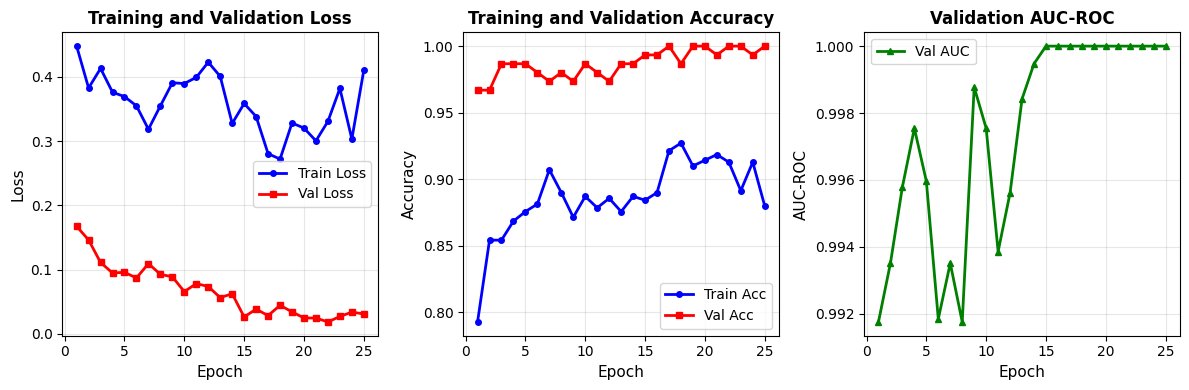

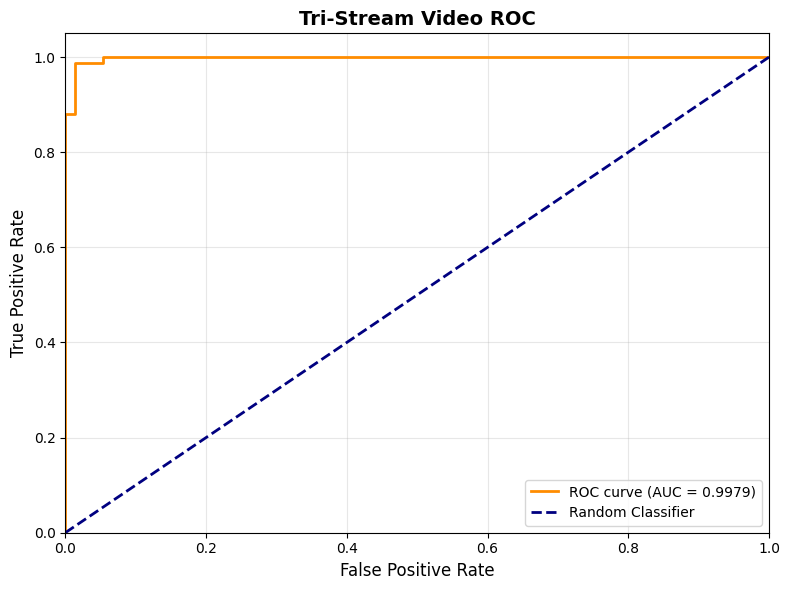

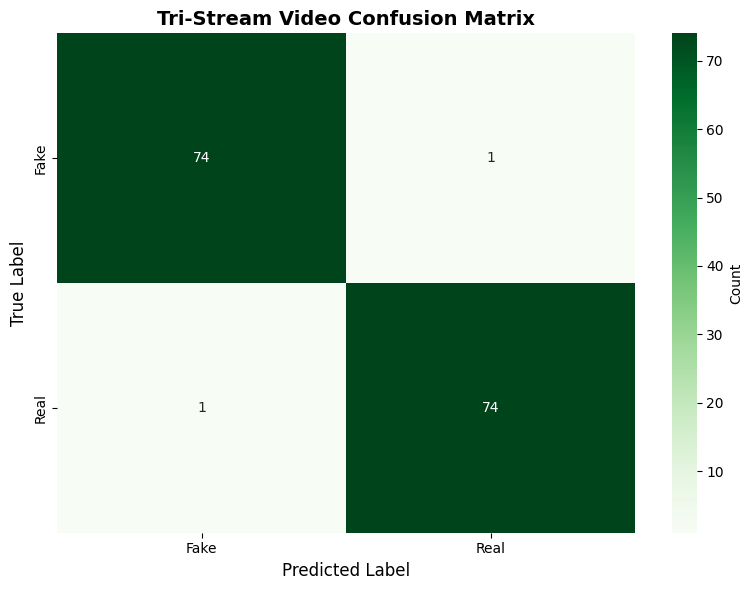

In [8]:
plot_training_history(
    history['train_loss'], history['val_loss'],
    history['train_acc'], history['val_acc'], history['val_auc'],
    save_path='../results/tristream_training_curves.png',
)

plot_roc_curve(labels_fake, probs_fake,
               title='Tri-Stream Video ROC', save_path='../results/tristream_roc.png')
plot_confusion_matrix(test_results['all_labels'], test_results['all_preds'],
                      title='Tri-Stream Video Confusion Matrix',
                      save_path='../results/tristream_cm.png');